
# Session 7 — Simulations for Total Probability & Bayes

**Topics:** Conditional probability, Law of Total Probability (LTP), Bayes’ theorem, simulations

**What you'll do:**
- Simulate the **Monty Hall** problem.
- Simulate a **3-urn** experiment compare to LTP.
- Solve a **tulip bulbs** Bayes problem analytically and via simulation.
- Solve a **medical test** Bayes problem (rare disease) analytically and via simulation.


In [ ]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt




## A) Monty Hall Simulation (Stay vs Switch)

**Game:**  
1. There are 3 doors: 1 hides a **car**, 2 hide **goats**.  
2. You pick a door at random (no information).  
3. The host opens a different door showing a **goat**.  
4. You can **stay** with your original door or **switch** to the other closed door.

**Theory:** Staying wins with probability **1/3**; switching wins with probability **2/3**.  
We verify this via simulation.


In [21]:

#Three different doors:
doors = np.array(['car', 'first goat', 'second goat'])

#There are two goat, first goat and second goat
goats = np.array(['first goat', 'second goat'])

## The idea is to create a function monty_hall which returns an array with the three doors; car, first goat, second goat.
## This represent 'Guess', 'Revealed', 'Remaining'
## The array will depend on the random choice of your door.
## For example if you select first goat, because the host will show you a goat (second), the last door will have a car

#Create a game for 1 time
def monty_hall():

  #You select randomly 1 door
  your_choice =

  #Then depending on the host choice and find the remaning door
  #if your choise is "first goat"
  if your_choice == 'first goat':
      host_choice =
      remaining_door =

  elif

  #if your choise is "first car"
  elif

  return

In [ ]:
#Try one simulation
monty_hall()


Now that you have a function, run 25,000 times your function and try to
see if you retrieve the theoritical predictions.


In [ ]:
# you can use pandas
import pandas as pd
games=pd.DataFrame(columns=['Guess', 'Revealed', 'Remaining'])
#for i in range(25000):
#    games.loc[i, :] = monty_hall()

#print dataframe

In [36]:
#Now that you have a dataframe use groupby and size to count how many item for each
#category you have.

#First start with guess and then do remaining
#For both case rename Guess into Item and remaining into Item

original_choice =
original_choice

,Item,Original Door
0,car,8441
1,first goat,8321
2,second goat,8238


In [112]:
switch_choice =
switch_choice

,Item,Switch door
0,car,11954
1,first goat,3123
2,second goat,2971


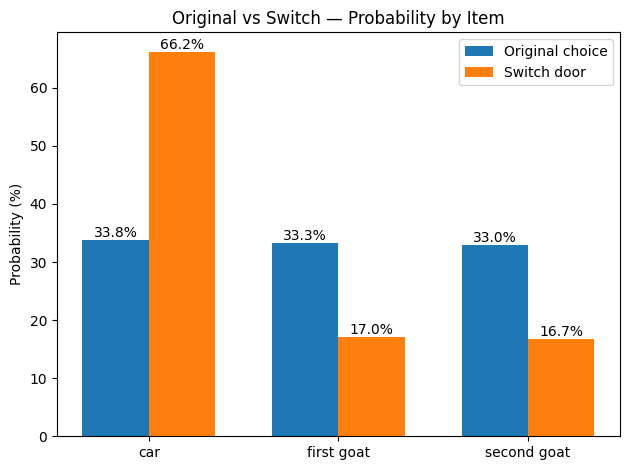

In [38]:
# Compute percentages within each table
original_choice['Original %'] =
switch_choice['Switch %']   =

# Combine on Item
comp = (
    original_choice[['Item','Original %']]
    .merge(switch_choice[['Item','Switch %']], on='Item', how='outer')
)

# Plot side-by-side bars


#  annotate bars with values

plt.show()


## B) Urnes (FR) — Simulation & LTP

**Problem :**  
We have three identical urns.

- The first contains two white balls and one black ball.
- The second contains three white balls and one black ball.
- The third contains two white balls and two black balls.

We choose one urn at random and draw a ball from it. We can determine the probability of drawing a white ball with this program, which simulates a series of 1,000 experiments.



In [60]:
#First urn


def one_draw():
    #return the ball color for one draw

    return ball

# Now simulate 1,000 experiments and estimate P(white)
def simu(n=1000):

    return p_W

p_W = simu(n=1000)
print(f"Probability of drawing a white ball P(white) ≈ {p_W:.4f}")

Probability of drawing a white ball P(white) ≈ 0.6420


In [ ]:
#Compare with the theory

p_theory =
print(f"Theory: {p_theory:.4f}")


## C) Tulip Bulbs

**Problem:** Each bag in a large box contains 25 tulip bulbs. Three-fourths of the bags are of Type A containing bulbs for 5 red and 20 yellow tulips; one-fourth of the bags are of Type B contain bulbs for 15 red and 10 yellow tulips. A bag is selected at random and one bulb is planted.

- What is the probability that the bulb will produce a red tulip?

Create a simulation and compare with the value found in class.

In [67]:


def one_draw():
    #Color of the tulip for one random bulb

    return tulip

# Now simulate 1,000 experiments and estimate P(R)
def simu(n=1000):

    return p_R

p_R= simu(n=10000)
print(f"Probability that the bulb will produce a red tulip  {p_R:.4f}")


Probability that the bulb will produce a red tulip  0.3002



## D) Medical Test

**Problem:**  
A certain disease affects about 1 out of 10,000 people. There is a test to check whether the person has the disease. The test is quite accurate. In particular, we know that the probability that the test result is positive, given that the person does not have the disease, is only 2 percent; the probability that the test result is negative, given that the person has the disease, is only 1 percent.

A random person gets tested for the disease and the result comes back positive. What is the probability that the person has the disease?


We verify with simulation.


In [97]:
'''
d=event that the person has the disease
p= event that the test result is true/positive.

P(d)=1/10000
P(p|dc)=0.02
P(pc|d)=0.01 -> P(p|d)=0.99

'''

 #First create one test which tell you if the person has the disease and if the test is positive or not.

def one_test():
    # Does the person have the disease?
    u_d = random.random()
    d =          # disease with prob 0.0001

    # Test outcome conditional on disease
    u_t = random.random()
    p =

    return d, p

one_test()

(False, False)

In [108]:
#Do 100 000 simulations and save it as a DF
def simulate_df(n=100000):

    df = pd.DataFrame(data, columns=['disease', 'positive'])
    return df

df=simulate_df(n=1000000)


In [109]:
#Calculate the probability to have the disease when you are positive and compare with the value found in clase

#proba = df.loc[df['positive'], 'disease'].mean()
#print("Estimated P(D|+) in %:", proba*100)


Estimated P(D|+) in %: 0.46197406984253137
